# 问题四：同类型EW电价基线—净负荷变化Ridge耦合预测与优化

本 Notebook 与配套 Markdown 采用最终保留方案：**最近8个同负荷类型日的价格EW基线＋净负荷变化Ridge修正＋问题二/三原优化器**。坑14的极低价—光伏容量竞争只用于结构解释，不新增“低价必须充电”等人工规则。

- 问题4-2：预测、机会约束、储能与结算规则与问题二一致；
- 问题4-3：卡尔曼融合、四阶段调整和不调整带与问题三一致；
- 本问新增：偏相关、未知未来电价预测、预测价优化与真实价结算。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Image
import q4_pipeline as q4

font_path=Path(r'C:\Windows\Fonts\msyh.ttc')
font_manager.fontManager.addfont(font_path)
cn_name=font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams.update({'font.sans-serif':[cn_name,'DejaVu Sans'],'axes.unicode_minus':False})

ROOT=Path.cwd()
BASE=Path(r'C:\Users\12055\Desktop\2026 国赛')
for f in ['EW一月选参.csv','偏相关指标.csv','价格预测指标.csv','EW价格预测指标.csv','EW与7日基线_优化费用对比.csv','EW方案运行验证.json']:
    assert (ROOT/f).exists(), f'缺少结果文件：{f}'
print('输入与已完成全年滚动仿真结果检查通过。')

输入与已完成全年滚动仿真结果检查通过。


## 1. 信息边界与单向耦合

每个决策时刻只使用当时已经揭晓的数据：

$$
\mathcal I_\tau\rightarrow\widehat N_{t\mid\tau}
\rightarrow\widehat p_{t\mid\tau}\rightarrow\mathrm{LP}.
$$

预测电价进入优化目标；真实电价只在执行后用于计划费、调整费和紧急购电费结算。

## 2. 偏相关证据

In [2]:
dep=pd.read_csv(ROOT/'偏相关指标.csv')
display(dep)
print('控制144个日内时段、星期、年内sin/cos和线性趋势；区间按完整日期block bootstrap。相关不解释为因果。')

,范围,raw_pearson,raw_spearman,partial_pearson,partial_spearman,ci_low,ci_high,bootstrap_days
0,全年,0.260170,0.262376,0.847254,0.843170,0.840030,0.854713,400
1,一月,0.166436,0.217987,0.841987,0.827048,0.804085,0.871984,400


控制144个日内时段、星期、年内sin/cos和线性趋势；区间按完整日期block bootstrap。相关不解释为因果。


## 3. 一月两类日型的电价分布

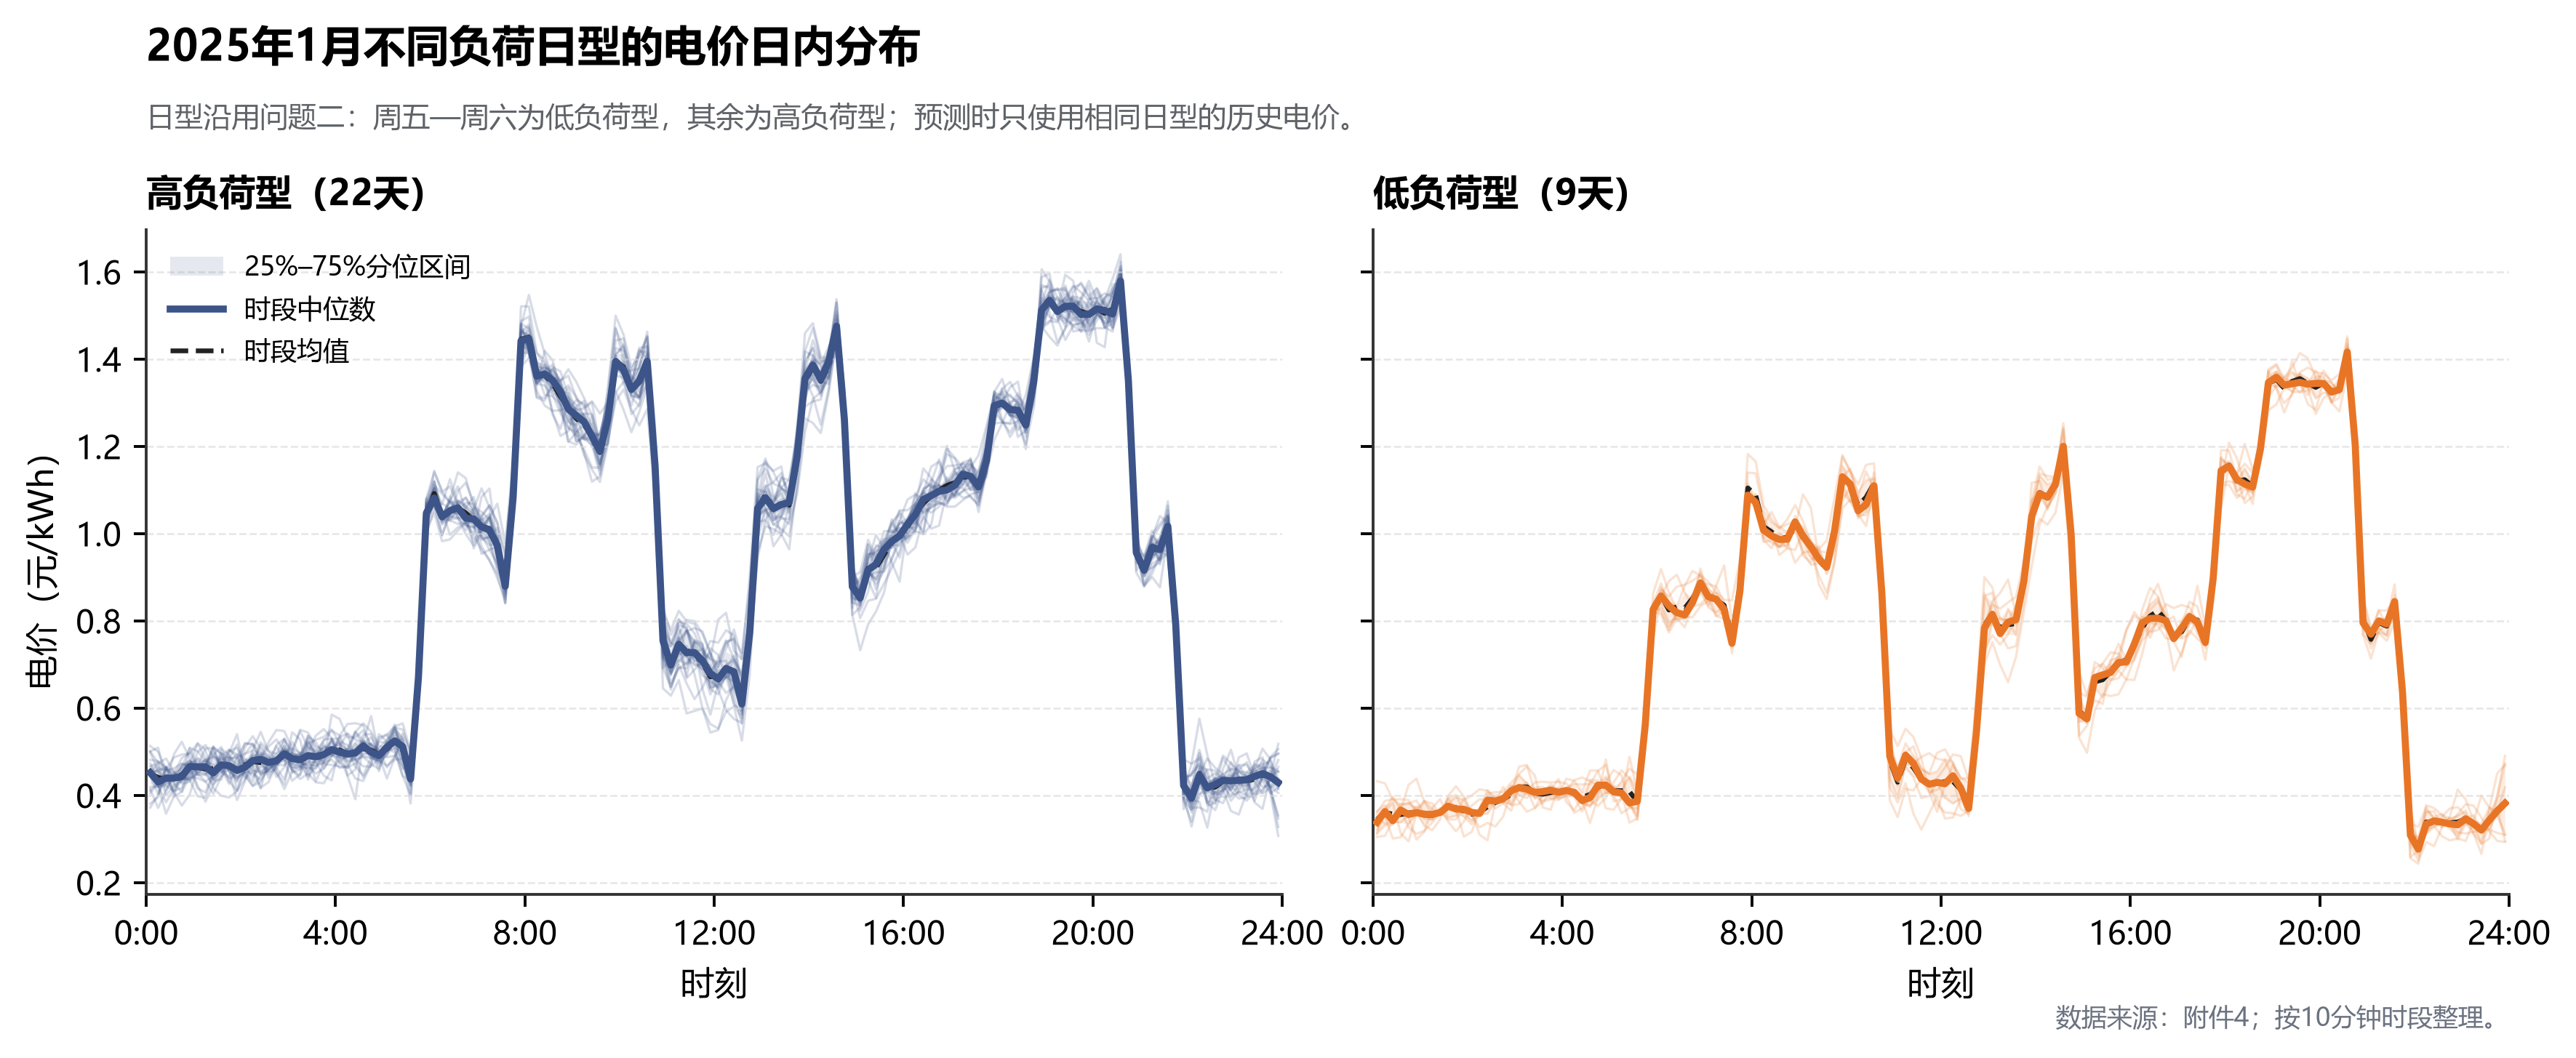

高/低负荷型沿用问题二划分，并作为价格EW筛选历史日的类别条件。


In [3]:
display(Image(filename=str(ROOT/'图表'/'问题四_一月电价分类型日内分布_双图无编号.png')))
print('高/低负荷型沿用问题二划分，并作为价格EW筛选历史日的类别条件。')

## 4. 同类型EW基线＋Ridge修正

沿用问题二日型：周五、周六为低负荷型，其余日期为高负荷型。对每个绝对目标时段，从发布时刻前寻找最近 $N$ 个**同负荷类型日、同一日内时段**：

$$
\bar p_{d,t}^{\rm EW}=\frac{\sum_{j\in\mathcal H_c(d,t)}\lambda^{r(j)}p_{j,t}}{\sum_{j\in\mathcal H_c(d,t)}\lambda^{r(j)}},\qquad
\bar N_{d,t}^{\rm EW}=\frac{\sum_{j\in\mathcal H_c(d,t)}\lambda^{r(j)}N_{j,t}}{\sum_{j\in\mathcal H_c(d,t)}\lambda^{r(j)}}.
$$

唯一交叉特征及最终预测为

$$
x_{d,t\mid\tau}=\widehat N_{d,t\mid\tau}-\bar N_{d,t}^{\rm EW},
$$

$$
\boxed{\widehat p_{d,t\mid\tau}=\bar p_{d,t}^{\rm EW}+f_{\rm Ridge}(x_{d,t\mid\tau}).}
$$

StandardScaler与Ridge在最近不超过42天的历史可得样本上滚动拟合，Ridge取 $\alpha=1$。

### 4.1 仅用一月选择EW参数

In [4]:
selection=pd.read_csv(ROOT/'EW一月选参.csv')
display(selection)
best=selection.iloc[0]
assert int(best['历史同类型日数N'])==8 and np.isclose(best['衰减系数lambda'],.8)
print('冻结参数：最近8个同类型日，lambda=0.8，Ridge alpha=1；2—12月不反向参与选模。')

,历史同类型日数N,衰减系数lambda,一月14—31日MAE,一月14—31日RMSE
0,8,0.8,0.029511,0.037666
1,8,0.6,0.030470,0.038919
2,4,0.8,0.030508,0.038880
3,4,0.6,0.031046,0.039606
4,8,0.4,0.031956,0.040742
5,4,0.4,0.032119,0.040940
6,2,0.8,0.032272,0.041151
7,2,0.6,0.032547,0.041498
8,2,0.4,0.033096,0.042161


冻结参数：最近8个同类型日，lambda=0.8，Ridge alpha=1；2—12月不反向参与选模。


## 5. 样本外价格预测效果

In [5]:
old=pd.read_csv(ROOT/'价格预测指标.csv')
ew=pd.read_csv(ROOT/'EW价格预测指标.csv')
comparison=old[['评价期','耦合预测_MAE','耦合预测_RMSE']].merge(ew,on='评价期').rename(columns={'耦合预测_MAE':'7日基线+Ridge_MAE','耦合预测_RMSE':'7日基线+Ridge_RMSE'})
display(comparison)
r=comparison.loc[comparison['评价期']=='2—12月'].iloc[0]
reduction=(r['7日基线+Ridge_MAE']-r['同类型EW_Ridge_MAE'])/r['7日基线+Ridge_MAE']
print(f'2—12月MAE相对下降：{reduction:.2%}')

,评价期,7日基线+Ridge_MAE,7日基线+Ridge_RMSE,同类型EW_Ridge_MAE,同类型EW_Ridge_RMSE
0,一月14—31日,0.035653,0.045031,0.029511,0.037666
1,2—12月,0.042440,0.058219,0.036034,0.049446


2—12月MAE相对下降：15.09%


## 6. 接入问题4-2与问题4-3优化

问题4-2保留小区负荷、光伏和电网购电的显式分离LP，每日0:00规划48小时、执行前24小时。问题4-3在0:00、6:00、12:00、18:00先更新净负荷，再同步更新未来48小时电价预测，仅调整未执行区间。SOC按实际执行状态连续传递；调整费仍以0:00原计划为基准。

,方案,价格模型,总费用_万元,相对旧模型节省_万元
0,问题4-2,7日基线+Ridge,1434.291505,0.000000
1,问题4-2,同类型8日EW(λ=0.8)+Ridge,1430.877553,3.413952
2,问题4-3,7日基线+Ridge,1389.381453,0.000000
3,问题4-3,同类型8日EW(λ=0.8)+Ridge,1385.461828,3.919625


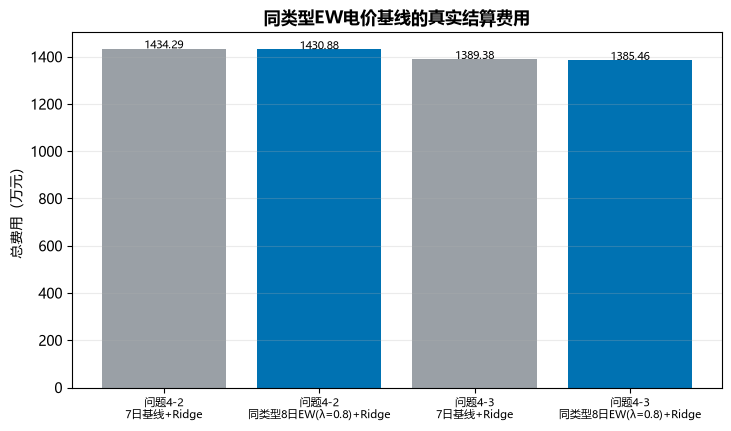

In [6]:
costs=pd.read_csv(ROOT/'EW与7日基线_优化费用对比.csv')
costs['总费用_万元']=costs['总费用_元']/1e4
costs['相对旧模型节省_万元']=costs['相对旧模型节省_元']/1e4
display(costs[['方案','价格模型','总费用_万元','相对旧模型节省_万元']])

fig,ax=plt.subplots(figsize=(7.2,4.2),constrained_layout=True)
labels=[]; vals=[]; colors=[]
for _,row in costs.iterrows():
    labels.append(row['方案']+'\n'+row['价格模型']); vals.append(row['总费用_万元']); colors.append('#9AA0A6' if '7日' in row['价格模型'] else '#0072B2')
ax.bar(labels,vals,color=colors)
ax.set_title('同类型EW电价基线的真实结算费用',fontweight='bold')
ax.set_ylabel('总费用（万元）'); ax.tick_params(axis='x',labelsize=8); ax.grid(axis='y',alpha=.25)
for i,v in enumerate(vals): ax.text(i,v+1,f'{v:.2f}',ha='center',fontsize=8)
fig.savefig(ROOT/'图表'/'问题四_EW与7日基线费用对比.png',dpi=300,bbox_inches='tight',facecolor='white')
plt.show()

## 7. 坑14：极低价与免费光伏的容量竞争

In [7]:
price=pd.read_excel(BASE/'附件4.xlsx').iloc[:,1:].to_numpy(float)
load=pd.read_excel(BASE/'附件2.xlsx',sheet_name='小区负载').iloc[:,1:].to_numpy(float)
pv=pd.read_excel(BASE/'附件2.xlsx',sheet_name='光伏发电实际功率').iloc[:,1:].to_numpy(float)
low=price<.1; surplus=np.maximum(pv-load,0)/6
pit14=pd.Series({'最低电价_元每kWh':price.min(),'<0.1时段数':int(low.sum()),'涉及天数':int(low.any(1).sum()),'低价且光伏过剩时段数':int((low&(surplus>0)).sum()),'对应光伏过剩电量_kWh':float(surplus[low].sum())})
display(pit14)
assert int((low&(surplus>0)).sum())==int(low.sum())
print('全部极低价时段都同时存在光伏过剩；该结构用于解释容量竞争，不新增低价强制充电规则。')

最低电价_元每kWh          0.007600
<0.1时段数            28.000000
涉及天数               12.000000
低价且光伏过剩时段数         28.000000
对应光伏过剩电量_kWh    28134.828333
dtype: float64

全部极低价时段都同时存在光伏过剩；该结构用于解释容量竞争，不新增低价强制充电规则。


近零电价购电的边际成本接近于零，但仍严格高于免费光伏。两者竞争相同的充电功率与SOC空间，最优选择由48小时价格、光伏、负荷和储能机会成本共同决定，不能简化为“低价就充电”的贪心规则。

## 8. 验证与局限

In [8]:
checks=json.loads((ROOT/'EW方案运行验证.json').read_text(encoding='utf-8'))
display(pd.Series(checks,name='验证结果'))
assert all(checks.values())
for stem in ['result4-2','result4-3']:
    report=q4.validate_excel(BASE/'附件5'/f'{stem}.xlsx',ROOT/'EW方案结果'/f'{stem}.xlsx',stem)
    assert all(report.values()),report
print('全部LP、SOC边界与连续性、费用恒等式和结果Excel验证通过。')

same_type_price_ew             True
selection_uses_january_only    True
q2_lp_all_success              True
q3_lp_all_success              True
q2_soc_bounds                  True
q3_soc_bounds                  True
q2_soc_continuity              True
q3_soc_continuity              True
q2_cost_identity               True
q3_cost_identity               True
Name: 验证结果, dtype: bool

全部LP、SOC边界与连续性、费用恒等式和结果Excel验证通过。


### 局限

1. EW＋Ridge能够识别极低价时段的相对低位，但会平滑罕见极值的绝对幅度。
2. 继承问题二、三的48小时规划未设置硬终端SOC等式，全年窗口末SOC落在下界，存在有限时域末端效应。主结果为保持前问口径不擅自修改，后续可用终端SOC或终端价值做敏感性分析。

## 9. 可选：从原始附件重新运行全年EW方案

In [9]:
# 将下行改为True可从官方附件重新执行完整价格预测与全年问题4-2/4-3优化（耗时约数分钟）。
RUN_FULL=False
if RUN_FULL:
    from q4_ew_compare import run_compare
    run_compare(base=BASE,out_dir=ROOT)
else:
    print('本Notebook展示的是已实际完成并验证的全年运行结果；RUN_FULL=True可重新生成。')

本Notebook展示的是已实际完成并验证的全年运行结果；RUN_FULL=True可重新生成。


## 10. 结论

最终保留“最近8个同负荷类型日的价格EW基线＋净负荷变化Ridge修正＋问题二/三原滚动优化器”。相较7日基线＋Ridge，2—12月电价MAE下降15.09%；问题4-2和问题4-3真实结算总费用分别变化3.4140万元和3.9196万元。